In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

LOADING DATA

In [ ]:
df = pd.read_csv("customer_data.csv")

UNDERSTADING DATA

In [ ]:
df.head()
df.shape
df.info()
df.describe()

CLEANING DATA

CHECKING NULL OR NAAN VALUES AND COLUMN NAMES

In [43]:
df.isna().sum()
df.columns

Index(['customer_id', 'age', 'gender', 'department', 'salary', 'bonus'], dtype='object')

FILLING MISSING VALUES USING MEAN AND MEDIAN

In [44]:
df['age'].fillna(df['age'].median(), inplace=True)
df['bonus'].fillna(df['bonus'].mean() , inplace=True)

 REMOVING OUTLIERS :  IQR METHOD 

In [45]:
q1 = df['age'].quantile(0.25)
q3= df['age'].quantile(0.75)
IQR = q3-q1

df = df[(df['age']>=q1 - 1.5*IQR) & (df['age']<=q3 + 1.5*IQR)]

In [ ]:
# q1 = df['bonus'].quantile(0.25)
# q3= df['bonus'].quantile(0.75)
# IQR = q3-q1

# df = df[(df['bonus']>=q1 - 1.5*IQR) & (df['bonus']<=q3 + 1.5*IQR)]

df= df[df['bonus']<23000]
# df['bonus_log']= np.log1p(df['bonus'])

BOXPLOT TO IDENTIFY OUTLIERS

<Axes: xlabel='age'>

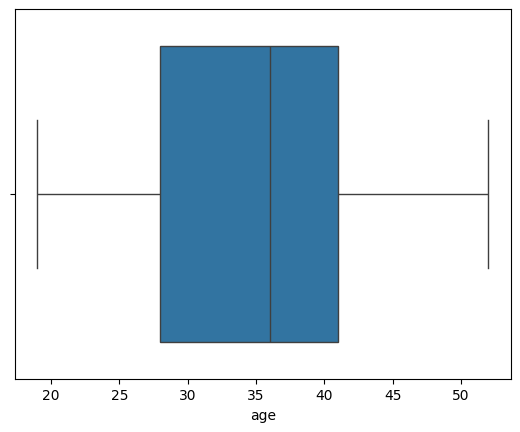

In [53]:
sns.boxplot(x=df['age'])

ENCODING CATEGORICAL DATA

In [ ]:
df = pd.get_dummies(df,columns=['gender','department'], drop_first=True)

NameError: name 'pd' is not defined

FEATURE ENGINEERING

In [47]:
df['Total_income'] = df['salary']+df['bonus']

RELATIONSHIP BETWEEN VARIABLES

<Axes: >

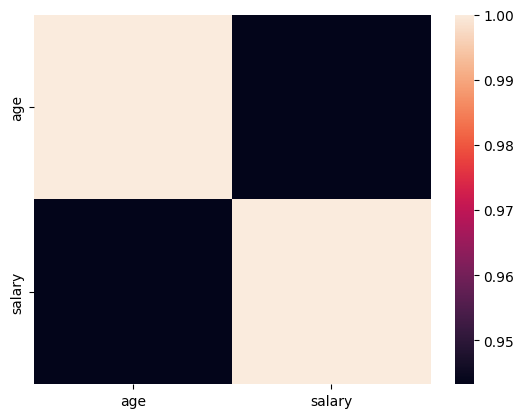

In [50]:
df_corr = df[['age','salary']].corr()
sns.heatmap(df_corr)

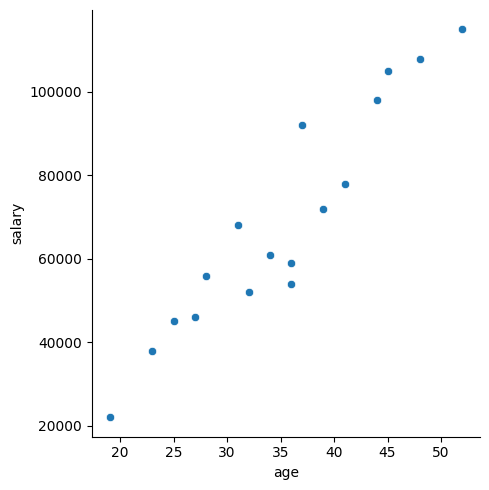

In [54]:
sns.relplot(x='age', y = 'salary' ,data=df)